# Ovarian cancer data analysis
Reproduce COMMOT results in `../../data/Ex1_hgsc/cmp/commot/`.

In [1]:
import commot as ct
import scanpy as sc
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

pltkw = dict(bbox_inches='tight', transparent=True)

In [3]:
# https://www.nature.com/articles/s41590-024-01943-5

## Load data

In [ ]:
regenerate = False

h5ad_file = "../../data/Ex1_hgsc/ST_Discovery_so.h5ad"
if (not os.path.exists(h5ad_file)) or regenerate:
    adata = sc.read_mtx("../../data/Ex1_hgsc/Csv/ST_Discovery_so_counts.mtx").T
    metadata = pd.read_csv("../../data/Ex1_hgsc/Csv/ST_Discovery_so_metadata.csv", index_col=0)
    features = pd.read_csv("../../data/Ex1_hgsc/Csv/ST_Discovery_so_features.txt", index_col=0, header=None)
    features.index = features.index.str.strip() # remove trailing white space in gene names
    features.index.name = 'gene_symbol'
    adata.obs = metadata
    adata.var = features
    adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()
    adata.write_h5ad(h5ad_file)
else:
    adata = sc.read_h5ad(h5ad_file)

In [ ]:
## Metadata and gene sets

sample_metadata = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", index_col=0, sheet_name='Table 2b', skiprows=1)
sample_metadata = sample_metadata[sample_metadata['dataset'] == 'Discovery']

celltype_signatures = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", sheet_name='Table 3a', skiprows=2)
mtil_signautures = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", sheet_name='Table 6a', skiprows=2)
desmoplasia_signautures = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", sheet_name='Table 5a', skiprows=2)

def purge_gene_sets(df, prefix=''):
    res = {}
    for i in df.columns:
        res[prefix + i] = df[i].dropna().tolist()
    return res
celltype_signatures = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", index_col=0, sheet_name='Table 3b', skiprows=2).iloc[:, :-3]
genesets = (purge_gene_sets(celltype_signatures, 'sig_') | 
            purge_gene_sets(mtil_signautures, 'mtil_') | 
            purge_gene_sets(mtil_signautures, 'mtil_'))
genesets.keys()
del genesets['sig_Mast.cell']

sample_metadata

,dataset,platform,n_cells,median_tpc,mean_tpc,TMA,patients,sites_binary,age,stage,...,fu_time2,outcome,pfs,BRCA1_Somatic,BRCA2_Somatic,TP53_Somatic,BRCA1_Germline,BRCA2_Germline,TP53_Germline,tmb
profile,,,,,,,,,,,,,,,,,,,,,
SMI_T10_F001,Discovery,SMI,5660,205.0,238.675618,TMA 10,HGSC1,Adnexa,58.0,III,...,775.0,Alive,775.0,WT,P,P,US,US,US,6.80
SMI_T10_F002,Discovery,SMI,8821,364.0,393.318671,TMA 10,HGSC7,Adnexa,58.0,III,...,1013.0,Alive,1013.0,P,WT,LP,US,US,US,0.53
SMI_T10_F003,Discovery,SMI,2881,300.0,445.154460,TMA 10,HGSC8,Adnexa,65.0,IV,...,781.0,Alive,200.0,WT,WT,P,US,US,US,3.16
SMI_T10_F004,Discovery,SMI,3145,286.0,376.895390,TMA 10,HGSC13,Omentum,67.0,III,...,840.0,Dead (disease),161.0,WT,WT,P,US,US,US,2.63
SMI_T10_F005,Discovery,SMI,2187,165.0,267.202561,TMA 10,HGSC15,Adnexa,33.0,IV,...,845.0,Alive,845.0,WT,WT,P,P,US,US,2.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMI_T14_F016,Discovery,SMI,2744,209.0,288.211735,TMA 14,HGSC61,Omentum,70.0,III,...,1955.0,Alive,1955.0,WT,WT,P,US,US,US,1.10
SMI_T14_F017,Discovery,SMI,3376,276.0,368.816647,TMA 14,HGSC63,Omentum,71.0,III,...,407.0,D/c to hospice (likely dead of disease),297.0,WT,WT,P,US,US,US,0.50
SMI_T14_F018,Discovery,SMI,9961,189.0,210.500452,TMA 14,HGSC89,Adnexa,53.0,III,...,1729.0,Dead (disease),412.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


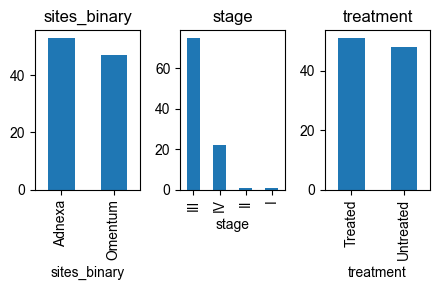

In [6]:
## Find untreated, adnexa samples

columns_of_interest = ['sites_binary', 'stage', 'treatment']
fig, axes = plt.subplots(1, len(columns_of_interest), figsize=(len(columns_of_interest) * 1.5, 3))
for i, column in enumerate(columns_of_interest):
    sample_metadata[column].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()

mask = (sample_metadata['sites_binary'] == 'Adnexa') & (sample_metadata['treatment'] == 'Untreated')
samples_of_interest = sample_metadata.index[mask].tolist()

all_adata = adata[adata.obs['samples'].isin(samples_of_interest)].copy()
all_adata.obs['cell.types.nolc'] = all_adata.obs['cell.types'].str.replace('_LC', '')

In [7]:
# selected_samples = np.random.choice(all_adata.obs['samples'].unique(), size=10, replace=False)
# all_adata = all_adata[all_adata.obs['samples'].isin(selected_samples)].copy()

In [8]:
# Separate individual slides
adatas = []
for i in all_adata.obs['samples'].unique():
    temp = all_adata[all_adata.obs['samples'] == i].copy()
    if temp.shape[0] < 100:
        continue
    adatas.append(temp)
    sc.pp.normalize_total(adatas[-1])
    sc.pp.log1p(adatas[-1])

In [9]:
df_ligrec=ct.pp.ligand_receptor_database(database='CellChat', species='human')

In [ ]:
for i in tqdm(range(16)):
    k = adatas[i].obs['samples'].unique().astype(str).item()
    adata = adatas[i]
    ct.tl.spatial_communication(adata,
        database_name='user_database', df_ligrec=df_ligrec, dis_thr=200, heteromeric=True)
    adata.write_h5ad(f"../output/hgsc_commot_{k}.h5ad")

100%|██████████| 16/16 [5:50:30<00:00, 1314.41s/it]  


In [ ]:
commot_cci = {}
for s in tqdm(range(len(adatas))):
    k = adatas[s].obs['samples'].unique().astype(str).item()
    adatas[s] = sc.read_h5ad(f"../output/hgsc_commot_{k}.h5ad")
    cell_type_key = 'cell.types.nolc'
    pseudocount = 20.
    temp = pd.DataFrame(0,
                        index=adatas[s].obs[cell_type_key].cat.categories, 
                        columns=adatas[s].obs[cell_type_key].cat.categories)

    for i in temp.index:
        mask_i = adatas[s].obs[cell_type_key] == i
        for j in temp.columns:
            mask_j = adatas[s].obs[cell_type_key] == j
            sub_attnp = adatas[s].obsp['commot-user_database-total-total'][mask_i, :][:, mask_j]
            normalization_factor = sub_attnp.nnz + pseudocount
            temp.loc[i, j] = sub_attnp.sum() / normalization_factor
    temp.to_csv(f"../output/hgsc_commot_cci_{k}.csv")
    commot_cci[k] = temp

100%|██████████| 27/27 [00:23<00:00,  1.15it/s]


In [22]:
def melt_helper(x):
    x_melt = x.melt(ignore_index=False)
    x_melt['variable'] = x_melt.index + '_' + x_melt['variable']
    return x_melt

cellchat_corr_dict = {}

for k in tqdm(commot_cci.keys()):
    cellchat_res_path = f"../data/Ex1_hgsc/cellchat/{k}.csv"
    cellchat = pd.read_csv(cellchat_res_path, index_col=0)

    cellchat_melt = melt_helper(cellchat + cellchat.T)
    cellchat_melt

    commot_melt = melt_helper(commot_cci[k] + commot_cci[k].T)
    commot_melt

    all_melt = pd.merge(cellchat_melt, commot_melt, on='variable', suffixes=['_cellchat', '_commot'])

    corr_res = sp.stats.spearmanr(all_melt['value_cellchat'], all_melt['value_commot'])
    corr_res

    cellchat_corr_dict[k] = [corr_res.statistic, corr_res.pvalue]

100%|██████████| 27/27 [00:00<00:00, 87.66it/s] 


In [23]:
cellchat_corr_df = pd.DataFrame(cellchat_corr_dict, index=['commot_r', 'commot_p']).T
cellchat_corr_df

,commot_r,commot_p
SMI_T10_F001,0.498939,2.631908e-04
SMI_T10_F002,0.461111,4.648361e-03
SMI_T10_F006,0.734825,1.843561e-09
SMI_T10_F014,0.757481,2.980577e-10
SMI_T11_F001,0.728379,2.994767e-09
SMI_T11_F002,0.777254,5.129106e-11
SMI_T11_F004,0.722969,4.452865e-09
SMI_T11_F008,0.387234,1.963423e-02
SMI_T11_F009,0.752744,1.186459e-07
SMI_T11_F011,NaN,NaN
